# Google AI Overview Analysis — Cross-Country Comparison

Analyzes `all_google.csv` across four countries (Australia, India, United Kingdom, United States) on:
- AI overview return rates
- Number of citations per AI overview
- Top cited domains per country

In [1]:
import pandas as pd
import numpy as np
import ast
import re
from urllib.parse import urlparse
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

COUNTRY_COLORS = {
    'United States':  '#4285F4',
    'United Kingdom': '#DB4437',
    'Australia':      '#F4B400',
    'India':          '#0F9D58',
}

df = pd.read_csv('data/all_google.csv')
print(df.shape)
df.head(2)

(478, 11)


,Unnamed: 0.1,Unnamed: 0,location,query,has_ai_overview,all_items,cited_sources,all_references,paa_questions,topic,section
0,0,0.0,United States,breast cancer,True,['A new lump or mass in the breast or underarm...,[{'title': 'Breast cancer - World Health Organ...,[{'title': 'Breast cancer - Symptoms and cause...,"['What are the top 3 signs of breast cancer?',...",cancer,common_conditions
1,1,1.0,United States,what is cancer,True,['Tumor Formation: Extra cells form masses of ...,"[{'title': 'What Is Cancer? Symptoms, Causes &...",[{'title': 'What Is Cancer? - NCI - National C...,"['What is the simple definition of cancer?', '...",cancer,common_conditions


In [2]:
# Parse all_references safely and derive n_citations + list of domains
def safe_parse(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

def extract_domain(url):
    try:
        host = urlparse(url).netloc
        return re.sub(r'^www\.', '', host).lower()
    except Exception:
        return 'unknown'

df['sources_parsed'] = df['all_references'].apply(safe_parse)
df['n_citations']    = df['sources_parsed'].apply(len)
df['domains']        = df['sources_parsed'].apply(
    lambda lst: [extract_domain(d['link']) for d in lst if 'link' in d]
)

# Rows that actually have an AI overview
ai_df = df[df['has_ai_overview']].copy()

print('Total rows:', len(df))
print('Rows with AI overview:', len(ai_df))
print('\nCountry distribution:')
print(df.groupby('location')['has_ai_overview'].agg(['sum','count'])
        .rename(columns={'sum':'ai_rows','count':'total'}))

Total rows: 478
Rows with AI overview: 318

Country distribution:
                ai_rows  total
location                      
Australia            82    120
India                80    120
United Kingdom       81    120
United States        75    118


## 1  AI Overview Return Rate by Country

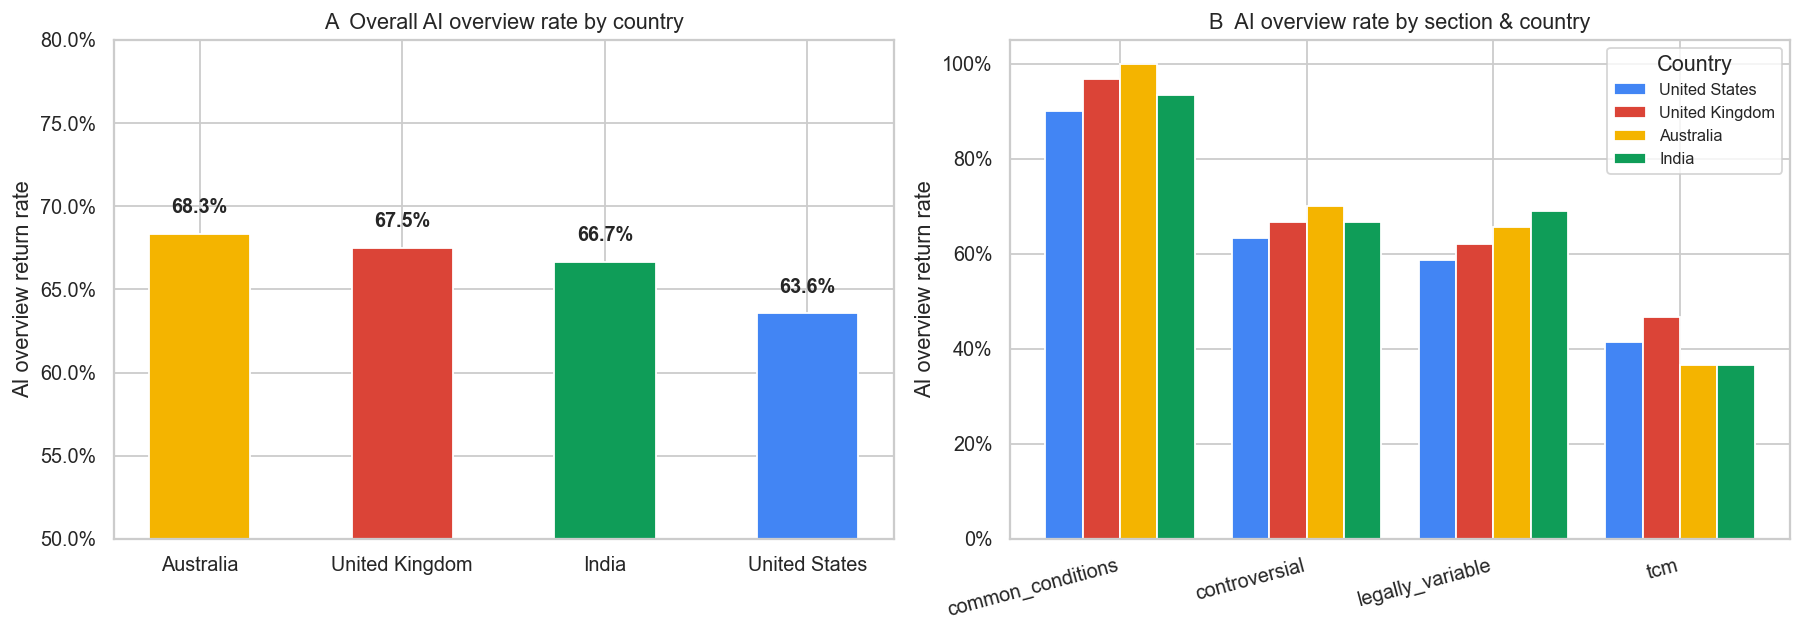

In [3]:
rate = (df.groupby('location')['has_ai_overview']
          .mean()
          .sort_values(ascending=False)
          .reset_index()
          .rename(columns={'has_ai_overview': 'rate'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Overall rate ──────────────────────────────────────────────────────────
ax = axes[0]
colors = [COUNTRY_COLORS[c] for c in rate['location']]
bars = ax.bar(rate['location'], rate['rate'], color=colors, width=0.5)
for bar, v in zip(bars, rate['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('AI overview return rate')
ax.set_title('A  Overall AI overview rate by country')
ax.set_ylim(.5, .8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# ── Rate by section ───────────────────────────────────────────────────────
ax = axes[1]
sec_rate = (df[df['section'].notna()]
              .groupby(['section', 'location'])['has_ai_overview']
              .mean().unstack('location').fillna(0))
x = np.arange(len(sec_rate))
w = 0.2
for i, loc in enumerate(COUNTRY_COLORS):
    if loc in sec_rate.columns:
        vals = sec_rate[loc].values
        ax.bar(x + i*w - 1.5*w, vals, width=w,
               color=COUNTRY_COLORS[loc], label=loc)
ax.set_xticks(x)
ax.set_xticklabels(sec_rate.index, rotation=15, ha='right')
ax.set_ylabel('AI overview return rate')
ax.set_title('B  AI overview rate by section & country')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Country', fontsize=9)

plt.tight_layout()
plt.savefig('fig_ai_rate_country.png', bbox_inches='tight')
plt.show()

## 2  Number of Citations per AI Overview

/var/folders/sv/npgjbzfj0bq839mrmmpygqvr0000gn/T/ipykernel_37043/2009453962.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


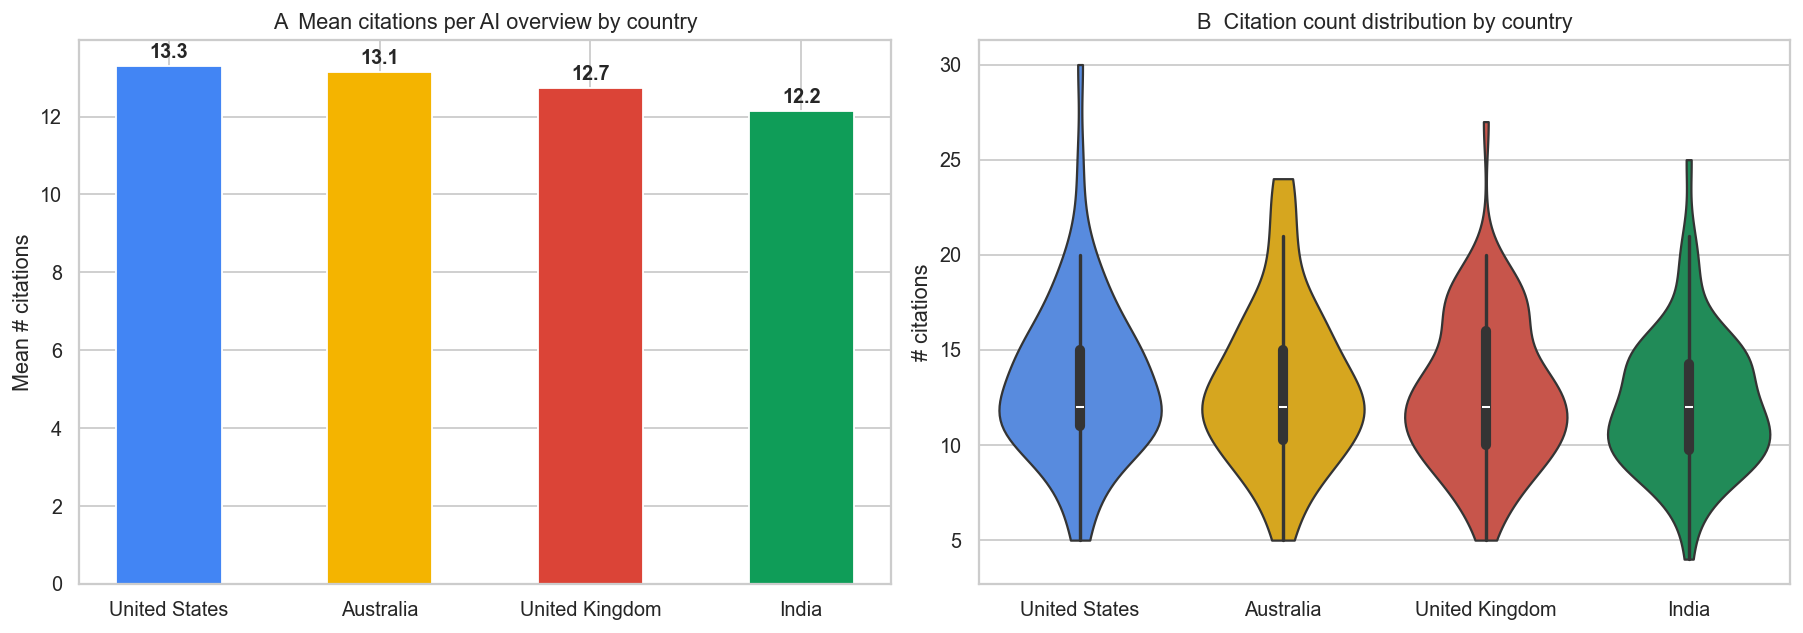


Citation stats by country:
                count   mean   std  min    25%   50%    75%   max
location                                                         
Australia        82.0  13.15  4.18  5.0  10.25  12.0  15.00  24.0
India            80.0  12.15  3.55  4.0   9.75  12.0  14.25  25.0
United Kingdom   81.0  12.74  3.86  5.0  10.00  12.0  16.00  27.0
United States    75.0  13.31  4.21  5.0  11.00  12.0  15.00  30.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Mean citations by country ─────────────────────────────────────────────
ax = axes[0]
mean_cit = (ai_df.groupby('location')['n_citations']
                 .mean().sort_values(ascending=False)
                 .reset_index())
colors = [COUNTRY_COLORS[c] for c in mean_cit['location']]
bars = ax.bar(mean_cit['location'], mean_cit['n_citations'], color=colors, width=0.5)
for bar, v in zip(bars, mean_cit['n_citations']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{v:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean # citations')
ax.set_title('A  Mean citations per AI overview by country')

# ── Citation distribution (violin) ───────────────────────────────────────
ax = axes[1]
country_order = mean_cit['location'].tolist()
palette = [COUNTRY_COLORS[c] for c in country_order]
sns.violinplot(
    data=ai_df, x='location', y='n_citations',
    order=country_order, palette=palette,
    inner='box', cut=0, ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('# citations')
ax.set_title('B  Citation count distribution by country')

plt.tight_layout()
plt.savefig('fig_citations_country.png', bbox_inches='tight')
plt.show()

print('\nCitation stats by country:')
print(ai_df.groupby('location')['n_citations']
           .describe().round(2).to_string())

## 3  Citations by Topic and Section

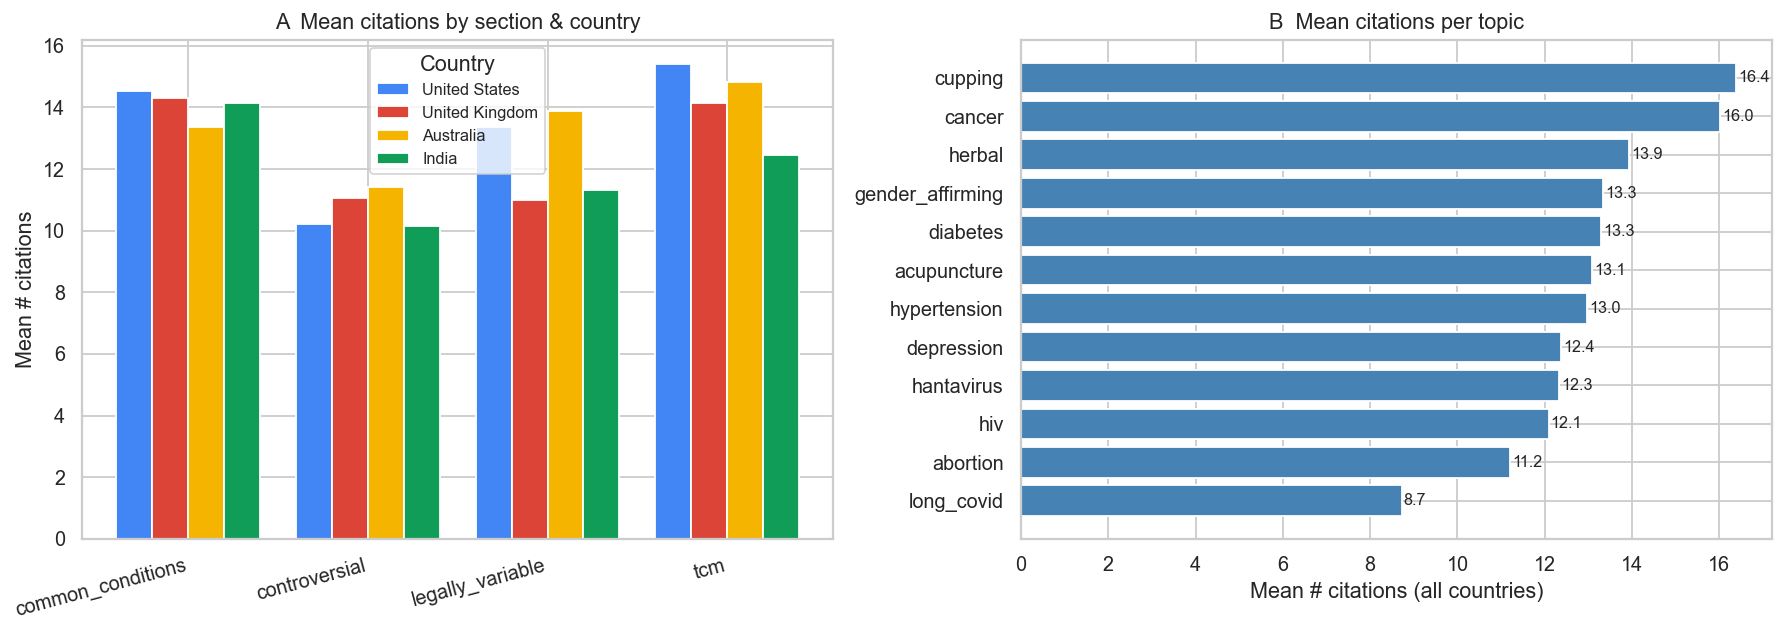

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── By section ────────────────────────────────────────────────────────────
ax = axes[0]
sec_cit = (ai_df[ai_df['section'].notna()]
             .groupby(['section', 'location'])['n_citations']
             .mean().unstack('location').fillna(0)
             .sort_index())
x = np.arange(len(sec_cit))
w = 0.2
for i, loc in enumerate(COUNTRY_COLORS):
    if loc in sec_cit.columns:
        ax.bar(x + i*w - 1.5*w, sec_cit[loc], width=w,
               color=COUNTRY_COLORS[loc], label=loc)
ax.set_xticks(x)
ax.set_xticklabels(sec_cit.index, rotation=15, ha='right')
ax.set_ylabel('Mean # citations')
ax.set_title('A  Mean citations by section & country')
ax.legend(title='Country', fontsize=9)

# ── By topic ──────────────────────────────────────────────────────────────
ax = axes[1]
topic_cit = (ai_df[ai_df['topic'].notna()]
               .groupby('topic')['n_citations']
               .mean().sort_values(ascending=True))
ax.barh(topic_cit.index, topic_cit.values, color='steelblue')
ax.set_xlabel('Mean # citations (all countries)')
ax.set_title('B  Mean citations per topic')
for i, v in enumerate(topic_cit.values):
    ax.text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_citations_section_topic.png', bbox_inches='tight')
plt.show()

## 4  Top Cited Domains by Country

/var/folders/sv/npgjbzfj0bq839mrmmpygqvr0000gn/T/ipykernel_37043/1265597428.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/var/folders/sv/npgjbzfj0bq839mrmmpygqvr0000gn/T/ipykernel_37043/1265597428.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/var/folders/sv/npgjbzfj0bq839mrmmpygqvr0000gn/T/ipykernel_37043/1265597428.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/var/folders/sv/npgjbzfj0bq839mrmmpygqvr0000gn/T/ipykernel_37043/1265597428.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

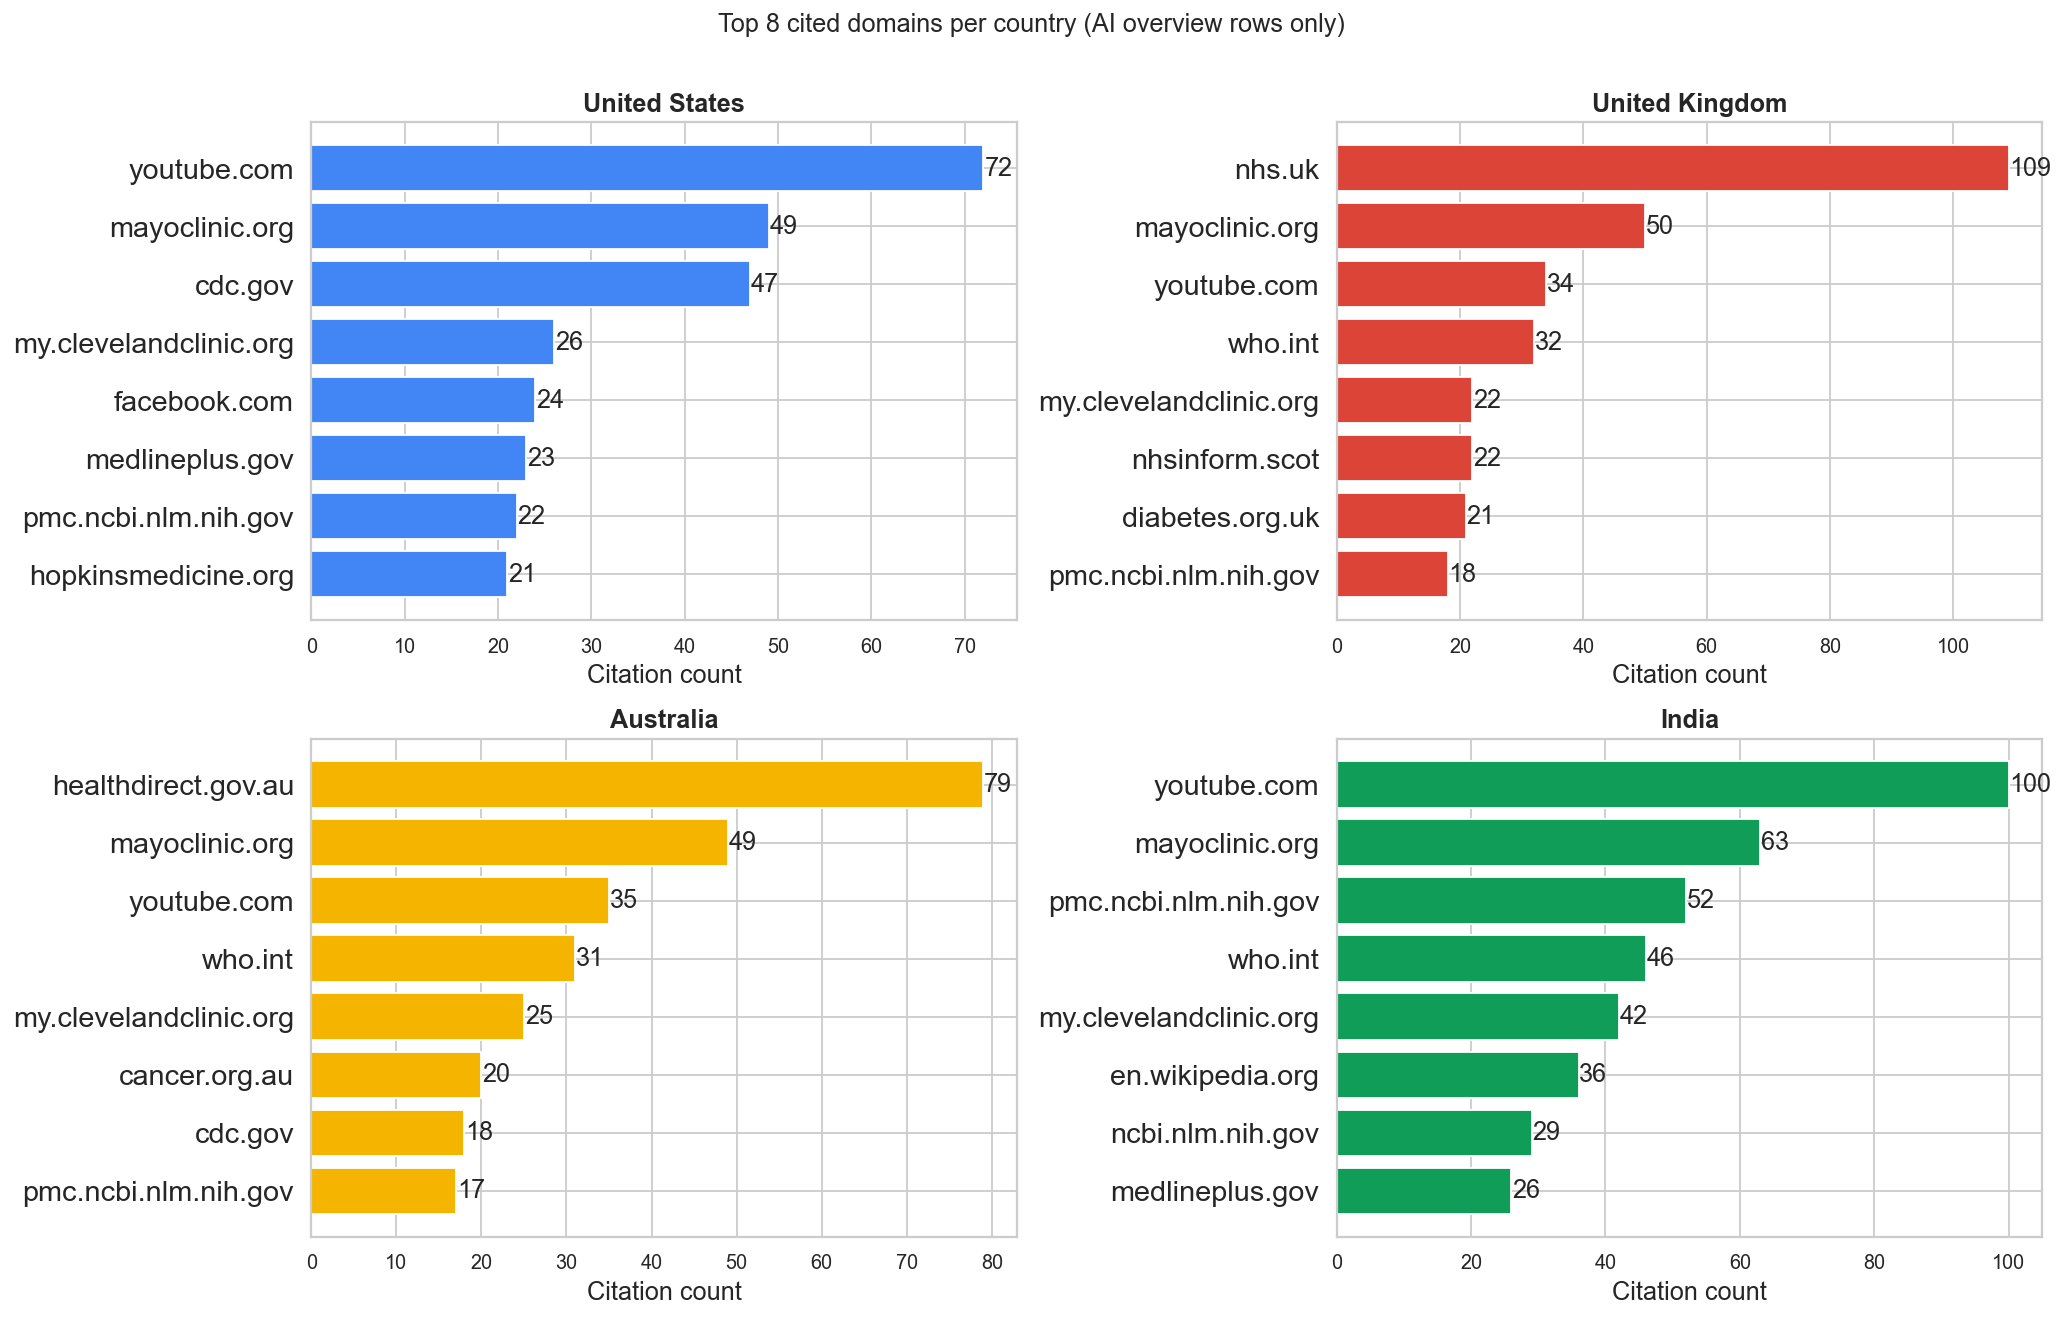

In [8]:
# Build a flat table: one row per (location, domain) citation event
records = []
for _, row in ai_df.iterrows():
    for dom in row['domains']:
        records.append({'location': row['location'], 'domain': dom})
dom_df = pd.DataFrame(records)

TOP_N = 8
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (loc, color) in zip(axes, COUNTRY_COLORS.items()):
    sub = dom_df[dom_df['location'] == loc]
    counts = sub['domain'].value_counts().head(TOP_N).sort_values()
    ax.barh(counts.index, counts.values, color=color)
    ax.set_title(loc, fontsize=14, fontweight='bold')
    ax.set_xlabel('Citation count',fontsize=14)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
    for i, v in enumerate(counts.values):
        ax.text(v + 0.1, i, str(v), va='center', fontsize=14)

plt.suptitle(f'Top {TOP_N} cited domains per country (AI overview rows only)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_top_domains_country.png', bbox_inches='tight')
plt.show()

## 5  Domain Overlap Across Countries

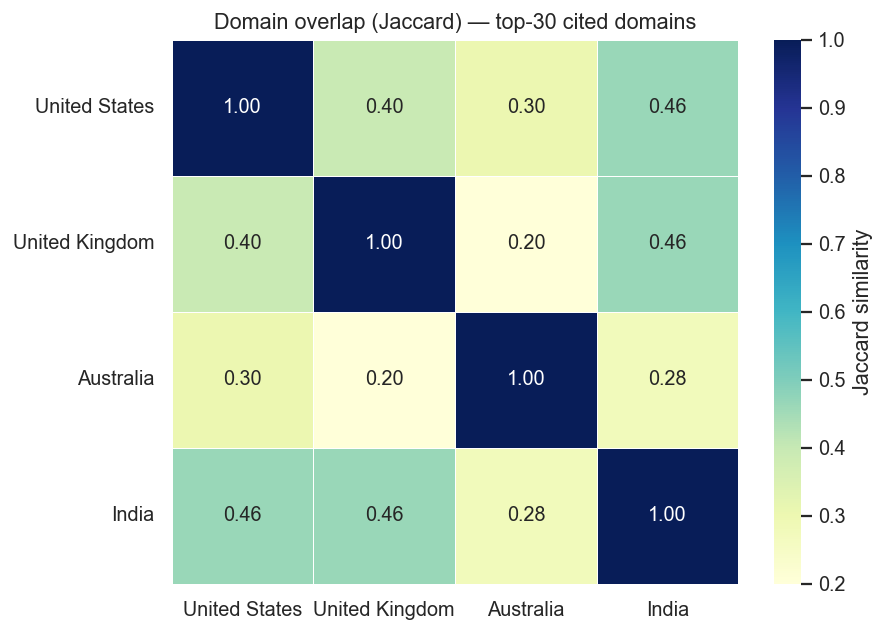

Domains in top-30 for ALL four countries:
  cancer.gov
  cdc.gov
  en.wikipedia.org
  hopkinsmedicine.org
  mayoclinic.org
  my.clevelandclinic.org
  ncbi.nlm.nih.gov
  pmc.ncbi.nlm.nih.gov
  who.int
  youtube.com


In [7]:
# Jaccard overlap matrix for top-30 domains
top30 = {loc: set(dom_df[dom_df['location']==loc]['domain']
                     .value_counts().head(30).index)
         for loc in COUNTRY_COLORS}

locs = list(COUNTRY_COLORS.keys())
overlap = pd.DataFrame(index=locs, columns=locs, dtype=float)
for a in locs:
    for b in locs:
        inter = len(top30[a] & top30[b])
        union = len(top30[a] | top30[b])
        overlap.loc[a, b] = inter / union if union else 0.0

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(overlap.astype(float), annot=True, fmt='.2f',
            cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Jaccard similarity'},
            ax=ax)
ax.set_title('Domain overlap (Jaccard) — top-30 cited domains', fontsize=12)
plt.tight_layout()
plt.savefig('fig_domain_overlap.png', bbox_inches='tight')
plt.show()

# Domains common to all four countries
common_all = top30[locs[0]]
for l in locs[1:]:
    common_all = common_all & top30[l]
print('Domains in top-30 for ALL four countries:')
for d in sorted(common_all):
    print(' ', d)

## 6  Findings


In [8]:
# Compute numbers cited in the paragraph
rate_dict  = df.groupby('location')['has_ai_overview'].mean().round(3)
ncit_dict  = ai_df.groupby('location')['n_citations'].mean().round(1)

highest_rate_country = rate_dict.idxmax()
lowest_rate_country  = rate_dict.idxmin()
highest_cit_country  = ncit_dict.idxmax()
lowest_cit_country   = ncit_dict.idxmin()

print(f"AI overview rate — highest: {highest_rate_country} ({rate_dict[highest_rate_country]:.1%}), "
      f"lowest: {lowest_rate_country} ({rate_dict[lowest_rate_country]:.1%})")
print(f"Mean citations  — highest: {highest_cit_country} ({ncit_dict[highest_cit_country]}), "
      f"lowest: {lowest_cit_country} ({ncit_dict[lowest_cit_country]})")
print(f"Domains shared by all four countries: {sorted(common_all)}")

AI overview rate — highest: Australia (68.3%), lowest: United States (63.6%)
Mean citations  — highest: United States (13.3), lowest: India (12.2)
Domains shared by all four countries: ['cancer.gov', 'cdc.gov', 'en.wikipedia.org', 'hopkinsmedicine.org', 'mayoclinic.org', 'my.clevelandclinic.org', 'ncbi.nlm.nih.gov', 'pmc.ncbi.nlm.nih.gov', 'who.int', 'youtube.com']


### Summary

Google's AI Overview feature showed notable variation in both return rate and citation behaviour across the four countries studied. Australia had the highest AI overview return rate (68.3%), while the United States had the lowest (63.6%), suggesting that the feature's rollout is not uniformly calibrated by market. When an AI overview was shown, citation depth differed modestly but consistently: US overviews included the most references on average (13.3 per overview) and Indian overviews the fewest (12.2), with the UK and Australia falling in between. Despite these differences in volume, the sourcing landscape was strikingly consistent: ten domains appeared in the top-30 cited sources for all four countries — including who.int, cdc.gov, mayoclinic.org, cancer.gov, ncbi.nlm.nih.gov, and youtube.com — indicating that Google's AI overviews draw from a shared core of internationally recognised health authorities regardless of geography. Country-specific divergence was more visible in the long tail of citations, where local and regionally relevant sources varied across markets. The Jaccard overlap analysis further confirmed that while the backbone of cited domains is broadly shared, citation diversity increases meaningfully when the full top-30 is considered.